In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from datasets import load_dataset  ## datasets load krvane me help kregi


## 2. Load Dataset
Load the dair-ai/emotion dataset from Hugging Face. https://huggingface.co/datasets/dair-ai/emotion

In [52]:
emotion_dataset = load_dataset('dair-ai/emotion')
emotion_dataset


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [84]:
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']
val_text = emotion_dataset['validation']['text']
val_label = emotion_dataset['validation']['label']

In [54]:
label_names = emotion_dataset['train'].features['label'].names

In [5]:
for i in train_label:
    print(label_names[i])

sadness
sadness
anger
love
anger
sadness
surprise
fear
joy
love
sadness
joy
anger
sadness
joy
joy
sadness
sadness
sadness
fear
anger
fear
joy
joy
anger
sadness
sadness
sadness
anger
joy
joy
fear
surprise
anger
joy
joy
joy
joy
anger
joy
joy
joy
joy
joy
sadness
sadness
joy
love
joy
anger
joy
sadness
anger
fear
joy
sadness
sadness
surprise
joy
joy
joy
love
fear
fear
surprise
anger
anger
sadness
love
joy
sadness
sadness
joy
sadness
sadness
sadness
joy
joy
joy
anger
sadness
anger
anger
anger
joy
joy
joy
joy
sadness
fear
love
anger
sadness
anger
love
sadness
joy
joy
sadness
anger
love
joy
joy
joy
sadness
joy
joy
joy
joy
sadness
joy
joy
love
sadness
sadness
joy
joy
sadness
joy
joy
fear
fear
fear
sadness
love
joy
joy
love
fear
surprise
joy
joy
joy
joy
anger
fear
joy
anger
love
anger
sadness
joy
sadness
anger
joy
surprise
sadness
anger
anger
sadness
joy
fear
joy
joy
fear
sadness
surprise
surprise
joy
anger
fear
anger
sadness
anger
sadness
fear
sadness
joy
surprise
fear
joy
anger
joy
anger
joy
f

In [85]:
df_train = pd.DataFrame({'text': train_text, 'label': [label_names[i] for i in train_label]})
df_test = pd.DataFrame({'text': test_text, 'label': [label_names[i] for i in test_label]})
df_val= pd.DataFrame({'text': val_text, 'label': [label_names[i] for i in val_label]})

In [11]:
df_train.head()


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [12]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

## EDA

<Axes: xlabel='label', ylabel='count'>

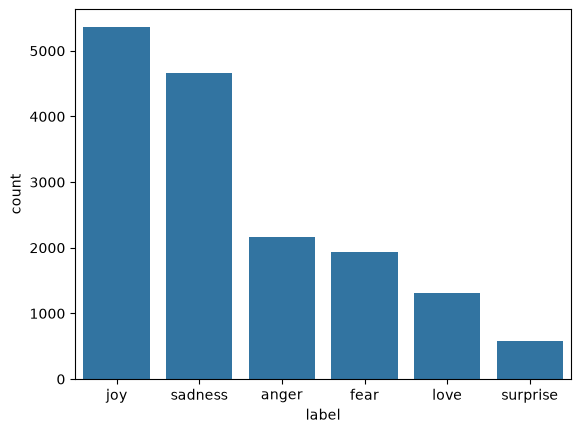

In [56]:
sns.countplot(x='label', data=df_train,order=df_train['label'].value_counts().index )

In [57]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


## Data Preprocessing - Using NLP

In [86]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece ,maxlen=50,padding='post', truncating='post')
padded_val_sequence = pad_sequences(tokenizer.texts_to_sequences(df_val['text']),maxlen=50,padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)
val_labels   = np.array(val_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


 ## 5. shared Traing Utilities
compute balanced class weights to handle dataset skew and setup early stoping 

In [87]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [88]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
early_stopping = EarlyStopping(
    monitor   ='val_loss',
    patience  =3, 
    restore_best_weights=True
    )



## 6. Plain Foundational Models
train plain(non-bidirectional) Simple RNN, Standard LSTM and Standard GRU models

In [89]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

d:\emotion-classification-nlp\venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [90]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_val_sequence, val_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")
     

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.1639 - loss: 2.0514 - val_accuracy: 0.2860 - val_loss: 1.6980
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.1433 - loss: 1.8791 - val_accuracy: 0.0745 - val_loss: 1.8176
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.1364 - loss: 1.8246 - val_accuracy: 0.0470 - val_loss: 1.8391
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.1301 - loss: 1.8071 - val_accuracy: 0.3500 - val_loss: 1.8028
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2980 - loss: 1.6911
RNN Loss: 1.6911296844482422
RNN Accuracy: 0.2980000078678131


## Standard LSTM

In [91]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_val_sequence, val_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 48ms/step - accuracy: 0.1577 - loss: 1.7946 - val_accuracy: 0.0890 - val_loss: 1.8288
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.1269 - loss: 1.7939 - val_accuracy: 0.1355 - val_loss: 1.7942
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - accuracy: 0.1548 - loss: 1.7914 - val_accuracy: 0.1310 - val_loss: 1.7928
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.2087 - loss: 1.7400 - val_accuracy: 0.3130 - val_loss: 1.6607
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.3898 - loss: 1.3385 - val_accuracy: 0.3820 - val_loss: 1.3326
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.5952 - loss: 0.8773 - val_accuracy: 0.7260 - val_loss: 0.8172
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.8163 - loss: 0.5312 - val_accuracy: 0.8620 - val_loss: 0.4961
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.8799 - loss: 0.3883 - 

## Standard GRU

In [92]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.1554 - loss: 1.7957 - val_accuracy: 0.1130 - val_loss: 1.8060
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.1528 - loss: 1.7953 - val_accuracy: 0.3465 - val_loss: 1.7805
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 46ms/step - accuracy: 0.1597 - loss: 1.7938 - val_accuracy: 0.0840 - val_loss: 1.7903
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.1562 - loss: 1.7926 - val_accuracy: 0.0840 - val_loss: 1.7935
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.1657 - loss: 1.7897 - val_accuracy: 0.0920 - val_loss: 1.7819
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3465 - loss: 1.7805
GRU Loss: 1.7804781198501587
GRU Accuracy: 0.3465000092983246


In [93]:
results_df=pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)
results_df

,Model,Test Loss,Test Accuracy
0,LSTM,0.372685,0.8985
1,GRU,1.780478,0.3465
2,RNN,1.691130,0.2980


## Advanced Bidirectional GRU
Enhance GRU with Bidirectional layers embeddings and 0.5 dropout regularization

In [94]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    #Why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

d:\emotion-classification-nlp\venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [95]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_val_sequence, val_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 103ms/step - accuracy: 0.5931 - loss: 1.0217 - val_accuracy: 0.8975 - val_loss: 0.3776
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 49s 98ms/step - accuracy: 0.9187 - loss: 0.2430 - val_accuracy: 0.9135 - val_loss: 0.2696
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 51s 101ms/step - accuracy: 0.9456 - loss: 0.1447 - val_accuracy: 0.9270 - val_loss: 0.2100
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 101ms/step - accuracy: 0.9603 - loss: 0.1082 - val_accuracy: 0.9200 - val_loss: 0.2659
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 101ms/step - accuracy: 0.9662 - loss: 0.0953 - val_accuracy: 0.9215 - val_loss: 0.2671
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 50s 100ms/step - accuracy: 0.9753 - loss: 0.0671 - val_accuracy: 0.9260 - val_loss: 0.2612


In [96]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9225 - loss: 0.2163
BiGRU Loss: 0.21626803278923035
BiGRU Accuracy: 0.9225000143051147


## Overall Evaluation & Bias Analysis

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step


<Axes: >

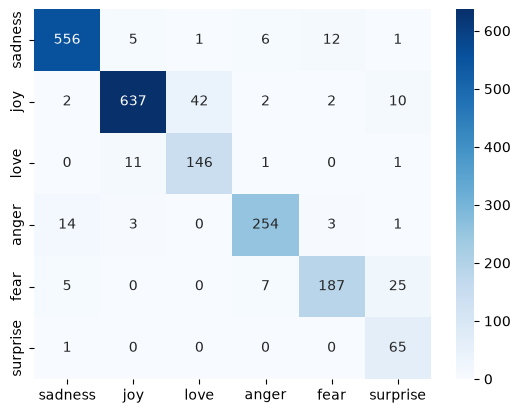

In [97]:
from sklearn.metrics import  confusion_matrix
BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequences), axis=1)

sns.heatmap(confusion_matrix(test_labels, BiGRU_predictions), annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)

## Final Predictions


In [98]:
sample_text = [
    "I got the job I always wanted!",
    "Today has been a wonderful day.",
    "I can't stop smiling after hearing the good news.",
    "I lost someone very close to me.",
    "Nothing seems to be going right today.",
    "I feel lonely and hopeless.",
    "This is absolutely unacceptable!",
    "I am really frustrated with what happened.",
    "How could they treat me like this?",
    "I heard a strange noise outside my room.",
    "I am nervous about what might happen.",
    "Walking alone in this place makes me uncomfortable.",
    "I am extremely grateful for everything you have done.",
    "I hate what happened today.",
    "I am excited about my vacation tomorrow.",
    "I suddenly heard a loud noise behind me.",
    "I am worried that I might lose my job.",
    "My best friend gave me a beautiful surprise.",
    "I don't want to talk to anyone today.",
    "I am furious about the unfair decision."
]
sequences = tokenizer.texts_to_sequences(sample_text)

padded_sequences = pad_sequences(
    sequences,
    maxlen=50,
    padding='post',
    truncating='post'
)

predictions = lstm_model.predict(padded_sequences)

predicted_classes = np.argmax(predictions, axis=1)

for text, pred in zip(sample_text, predicted_classes):
    print(f"Text: {text}")
    print(f"Predicted Emotion: {label_names[pred]}")
    print("-" * 60)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
Text: I got the job I always wanted!
Predicted Emotion: sadness
------------------------------------------------------------
Text: Today has been a wonderful day.
Predicted Emotion: sadness
------------------------------------------------------------
Text: I can't stop smiling after hearing the good news.
Predicted Emotion: sadness
------------------------------------------------------------
Text: I lost someone very close to me.
Predicted Emotion: sadness
------------------------------------------------------------
Text: Nothing seems to be going right today.
Predicted Emotion: sadness
------------------------------------------------------------
Text: I feel lonely and hopeless.
Predicted Emotion: sadness
------------------------------------------------------------
Text: This is absolutely unacceptable!
Predicted Emotion: sadness
------------------------------------------------------------
Text: I am really frustrated with what happened.
Predicte

In [101]:
sample_text = [
    "Today has been a wonderful day.",
    "I can't stop smiling after hearing the good news.",

    "I lost someone very close to me.",
    "Nothing seems to be going right today.",
    "I feel lonely and hopeless.",

    "I am really frustrated with what happened.",
    "How could they treat me like this?",

    "I heard a strange noise outside my room.",
    "I am nervous about what might happen.",
    "Walking alone in this place makes me uncomfortable.",

    "I never expected this to happen!",
    "Wow, I didn't see that coming.",
    "The news completely shocked me.",

    "I really appreciate everything you have done for me.",
    "I care deeply about my family.",
    "You are one of the most important people in my life."
]

sample_sequences = tokenizer.texts_to_sequences(sample_text)

sample_padded_sequences = pad_sequences(
    sample_sequences,
    maxlen=50,
    padding='post',
    truncating='post'
)

sample_predictions = np.argmax(
    BiGRU.predict(sample_padded_sequences),
    axis=1
)

for i in range(len(sample_text)):
    print(
        f"Text: {sample_text[i]}\n"
        f"Predicted Emotion: {label_names[sample_predictions[i]]}"
    ) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Text: Today has been a wonderful day.
Predicted Emotion: joy
Text: I can't stop smiling after hearing the good news.
Predicted Emotion: joy
Text: I lost someone very close to me.
Predicted Emotion: sadness
Text: Nothing seems to be going right today.
Predicted Emotion: sadness
Text: I feel lonely and hopeless.
Predicted Emotion: sadness
Text: I am really frustrated with what happened.
Predicted Emotion: anger
Text: How could they treat me like this?
Predicted Emotion: joy
Text: I heard a strange noise outside my room.
Predicted Emotion: surprise
Text: I am nervous about what might happen.
Predicted Emotion: fear
Text: Walking alone in this place makes me uncomfortable.
Predicted Emotion: fear
Text: I never expected this to happen!
Predicted Emotion: sadness
Text: Wow, I didn't see that coming.
Predicted Emotion: joy
Text: The news completely shocked me.
Predicted Emotion: surprise
Text: I really appreciate everything you have done for me.
Predicted

In [100]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = np.argmax(
    BiGRU.predict(padded_test_sequence),
    axis=1
)

print(classification_report(
    test_labels,
    y_pred,
    target_names=label_names,
    digits=4
))

cm = confusion_matrix(test_labels, y_pred)

print(cm)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
              precision    recall  f1-score   support

     sadness     0.9619    0.9570    0.9594       581
         joy     0.9710    0.9165    0.9430       695
        love     0.7725    0.9182    0.8391       159
       anger     0.9407    0.9236    0.9321       275
        fear     0.9167    0.8348    0.8738       224
    surprise     0.6311    0.9848    0.7692        66

    accuracy                         0.9225      2000
   macro avg     0.8657    0.9225    0.8861      2000
weighted avg     0.9311    0.9225    0.9245      2000

[[556   5   1   6  12   1]
 [  2 637  42   2   2  10]
 [  0  11 146   1   0   1]
 [ 14   3   0 254   3   1]
 [  5   0   0   7 187  25]
 [  1   0   0   0   0  65]]


## Save the Model & Tokenizer
Export trained model and tokenizer artifacts for API deplopment.

In [102]:
import os
import pickle

model_dir = "artifacts/models"
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)